# Lab 04: Regresión Logística Multiclase (One-vs-All)
**Cuadernillo 2: Dataset Multimodal**

##Estudiante:
* Delgado Ramos Jorge Luis

**Dataset:** FER-2013 (Facial Expression Recognition)

**Objetivo:** Clasificar 7 emociones humanas a partir de rostros de 48x48 píxeles.

## 1. Importación y Carga Inicial
En esta primera etapa, importamos las librerías base y cargamos el archivo CSV a la memoria. Al visualizar los datos originales, observaremos que las imágenes no vienen en un formato matricial convencional, sino que los valores de iluminación están encapsulados en cadenas de texto dentro de una única columna.

In [1]:
# Librerías
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Cargamos el dataset
print("Cargando el dataset FER-2013...")
ruta_dataset = '/content/drive/MyDrive/Colab Notebooks/SIS-420/Laboratorio 04/FER-2013.csv'
datos = pd.read_csv(ruta_dataset)

# Visualizamos la estructura cruda para evidenciar la necesidad de transformación
print("Estructura inicial del dataset:")
print(datos.head(3))

Cargando el dataset FER-2013...
Estructura inicial del dataset:
   emotion                                             pixels     Usage
0        0  70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...  Training
1        0  151 150 147 155 148 133 111 140 170 174 182 15...  Training
2        2  231 212 156 164 174 138 161 173 182 200 106 38...  Training


## 2. Extracción de Características
El principal reto técnico de este dataset reside en su estructura comprimida: los 2,304 píxeles (48x48) que conforman cada rostro vienen unidos por espacios en una sola celda de texto.

Para que la Regresión Logística pueda operar matemáticamente, se iteran las filas para "romper" (split) dichas cadenas de texto y transformarlas en arreglos numéricos (Numpy Arrays) de tipo flotante. Esto genera automáticamente nuestras **2,304 características ($n$)**.

In [4]:
# Paso 2: Transformar la columna de texto a una matriz matemática de píxeles
print("Transformando textos a matrices de píxeles...")
# Separamos la variable objetivo (las emociones del 0 al 6)
y_df = datos['emotion'].values
X_lista = []

# Iteramos sobre la columna gigante de texto
for secuencia in datos['pixels']:
    # Separamos por espacios y convertimos directamente a números flotantes
    pixeles = np.array(secuencia.split(' '), dtype=np.float32)
    X_lista.append(pixeles)

# Convertimos la lista resultante en nuestra matriz de diseño (X) oficial
X_df = np.array(X_lista)

m_total = X_df.shape[0]
n_caracteristicas = X_df.shape[1]

print(f"\n--- VERIFICACIÓN DE RESTRICCIONES MULTIMODALES ---")
print(f"Total de imágenes (m): {m_total} (Cumple m >= 5000)")
print(f"Píxeles/Características (n): {n_caracteristicas} (Cumple n >= 100)")

Transformando textos a matrices de píxeles...

--- VERIFICACIÓN DE RESTRICCIONES MULTIMODALES ---
Total de imágenes (m): 28709 (Cumple m >= 5000)
Píxeles/Características (n): 2304 (Cumple n >= 100)


## 3. División de Datos y Normalización
Las intensidades de los píxeles varían entre 0 (negro) y 255 (blanco). Para garantizar una convergencia rápida y uniforme del algoritmo del gradiente descendente, se requiere estandarizar estos valores.

**Prevención de Fuga de Información:**
Se apartó el 20% del dataset para la evaluación final. La normalización se aplicó extrayendo la media ($\mu$) y la desviación estándar ($\sigma$) **estrictamente** de la matriz de entrenamiento, aplicando luego estos mismos parámetros al conjunto de pruebas.

In [5]:
# Paso 3: División 80/20 y Normalización Estricta
X_train, X_test, y_train, y_test = train_test_split(X_df, y_df, test_size=0.20, random_state=42)

def normalizarPixeles(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

print("Estandarizando la iluminación de las imágenes (Normalización)...")
X_train_norm, mu_train, sigma_train = normalizarPixeles(X_train)
X_test_norm = (X_test - mu_train) / sigma_train

# Añadimos la columna de unos (x0 = 1) para el término de intersección theta_0
X_train_listo = np.concatenate([np.ones((len(X_train_norm), 1)), X_train_norm], axis=1)
X_test_listo = np.concatenate([np.ones((len(X_test_norm), 1)), X_test_norm], axis=1)

print("\nPreprocesamiento completado con éxito.")
print(f"Imágenes listas para entrenar: {X_train_listo.shape[0]}")
print(f"Características finales (2304 Píxeles + x0): {X_train_listo.shape[1]}")

Estandarizando la iluminación de las imágenes (Normalización)...

Preprocesamiento completado con éxito.
Imágenes listas para entrenar: 22967
Características finales (2304 Píxeles + x0): 2305


## 4. Definición Matemática del Modelo
Para este clasificador, se implementa la función **Sigmoide** como frontera de activación, la cual mapea las combinaciones lineales de los píxeles a un rango probabilístico de $[0, 1]$.

El entrenamiento se ejecuta mediante el algoritmo de **Descenso por el Gradiente Vectorizado**, optimizando la función de costo de Entropía Cruzada. Se han incluido mecanismos de protección numérica (`np.clip` y estabilizadores `epsilon`) para prevenir el desbordamiento aritmético típico al trabajar con exponenciales sobre miles de características.

In [6]:
# FASE 4: FUNCIONES MATEMÁTICAS

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -250, 250)))

def descensoGradiente(X, y, theta, alpha, num_iters):
    m = len(y)
    J_hist = []
    acc_hist = []
    epsilon = 1e-15

    for i in range(num_iters):
        h = sigmoid(X.dot(theta))

        # Actualización vectorizada de los parámetros (Thetas)
        theta = theta - (alpha / m) * (X.T.dot(h - y))

        # Cálculo de la función de Costo (Entropía Cruzada)
        costo = -(1/m) * np.sum(y * np.log(h + epsilon) + (1 - y) * np.log(1 - h + epsilon))
        J_hist.append(costo)

        # Cálculo de precisión en la iteración actual
        predicciones = (h >= 0.5).astype(int)
        precision = np.mean(predicciones == y) * 100
        acc_hist.append(precision)

    return theta, J_hist, acc_hist

print("Funciones matemáticas inicializadas en memoria.")

Funciones matemáticas inicializadas en memoria.


## 5. Entrenamiento Multiclase (One-vs-All)
Dado que el dataset incluye 7 emociones humanas distintas, se recurre a la estrategia **One-vs-All** (Uno contra Todos).

En lugar de un único modelo gigante, el bucle itera 7 veces para entrenar 7 clasificadores binarios independientes. Por ejemplo, el primer clasificador aprenderá a distinguir estrictamente patrones asociados al "Enojo" frente al resto de emociones combinadas. Todos los parámetros optimizados se almacenan en la matriz global `all_theta` ($7 \times 2305$).

Iniciando el entrenamiento multiclase masivo...
-> Entrenando modelo para detectar: Enojo...
-> Entrenando modelo para detectar: Asco...
-> Entrenando modelo para detectar: Miedo...
-> Entrenando modelo para detectar: Felicidad...
-> Entrenando modelo para detectar: Tristeza...
-> Entrenando modelo para detectar: Sorpresa...
-> Entrenando modelo para detectar: Neutral...

Entrenamiento completado para las 7 clases


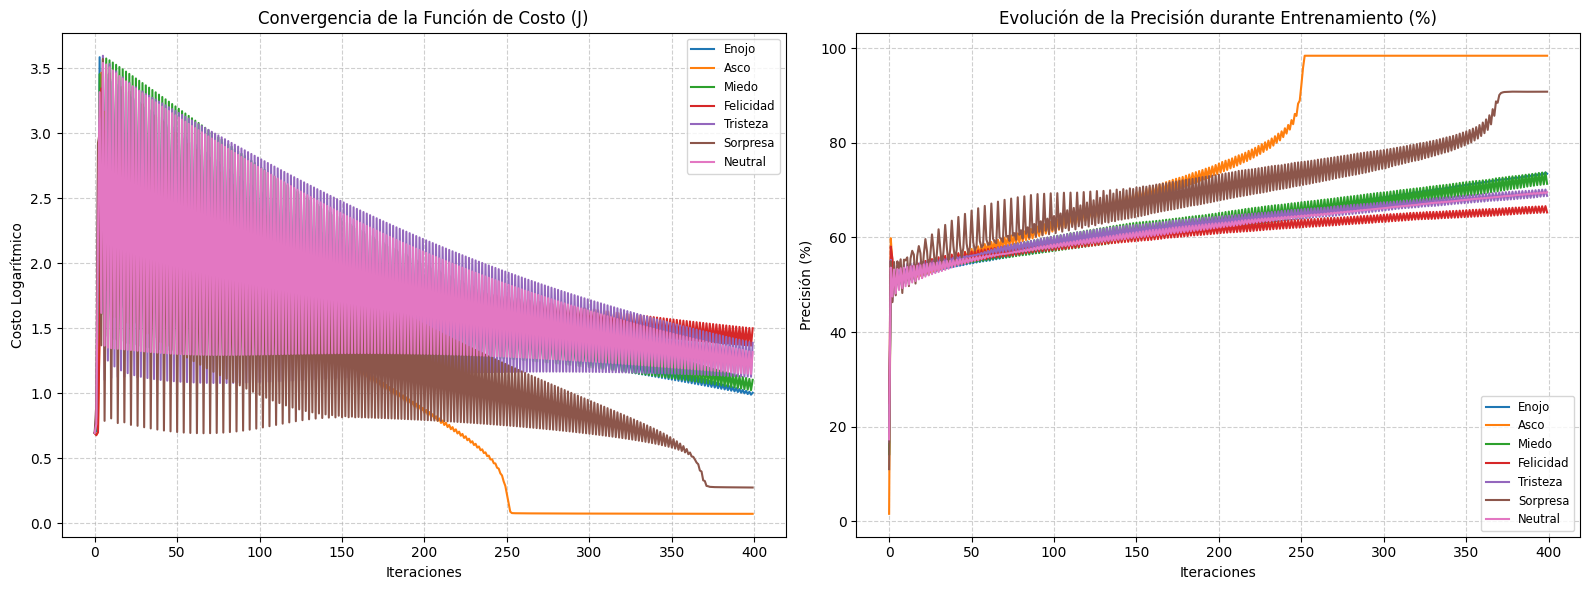

In [8]:
# FASE 5: ENTRENAMIENTO DE LOS 7 MODELOS DE EMOCIONES

# Etiquetas oficiales del dataset FER-2013
nombres_emociones = ['Enojo', 'Asco', 'Miedo', 'Felicidad', 'Tristeza', 'Sorpresa', 'Neutral']
num_clases = len(nombres_emociones)
n_features = X_train_listo.shape[1]

# Matriz para almacenar los thetas de los 7 modelos
all_theta = np.zeros((num_clases, n_features))

# Hiperparámetros (800 iteraciones para no sobrecargar la memoria con imágenes)
alpha = 0.05
iteraciones = 400

historiales_J = []
historiales_acc = []

print("Iniciando el entrenamiento multiclase masivo...")

for c in range(num_clases):
    # Transformación binaria: 1 si es la emoción actual, 0 si no lo es
    y_train_bin = (y_train == c).astype(int)

    theta_inicial = np.zeros(n_features)
    print(f"-> Entrenando modelo para detectar: {nombres_emociones[c]}...")

    theta_opt, J_hist, acc_hist = descensoGradiente(X_train_listo, y_train_bin, theta_inicial, alpha, iteraciones)

    all_theta[c, :] = theta_opt
    historiales_J.append(J_hist)
    historiales_acc.append(acc_hist)

print("\nEntrenamiento completado para las 7 clases")

# GRAFICACIÓN DE LOS RESULTADOS DEL APRENDIZAJE

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for c in range(num_clases):
    ax1.plot(historiales_J[c], label=nombres_emociones[c])
    ax2.plot(historiales_acc[c], label=nombres_emociones[c])

ax1.set_title('Convergencia de la Función de Costo (J)')
ax1.set_xlabel('Iteraciones')
ax1.set_ylabel('Costo Logarítmico')
ax1.legend(loc='upper right', fontsize='small')
ax1.grid(True, linestyle='--', alpha=0.6)

ax2.set_title('Evolución de la Precisión durante Entrenamiento (%)')
ax2.set_xlabel('Iteraciones')
ax2.set_ylabel('Precisión (%)')
ax2.legend(loc='lower right', fontsize='small')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## 6. Validación Final y Reconstrucción Visual
Con los 7 modelos optimizados, procedemos a evaluar el rendimiento real utilizando el conjunto de pruebas (`X_test`).

La función predictiva evalúa la probabilidad de las 7 clases de forma simultánea y selecciona la de mayor confianza mediante `np.argmax`. Para evidenciar la naturaleza multimodal del dataset, se realiza una operación matemática inversa: se extraen las 2,304 características numéricas (omitiendo el término de sesgo $x_0$) y se redimensionan (Reshape) a una matriz bidimensional de $48 \times 48$, permitiendo a la librería Matplotlib renderizar el rostro original junto con la predicción del algoritmo.

Evaluando el modelo contra las imágenes de prueba...

RESULTADO DEL DATASET MULTIMODAL
Imágenes evaluadas: 5742
PRECISIÓN GLOBAL: 28.47%

Generando reconstrucción visual de los rostros...


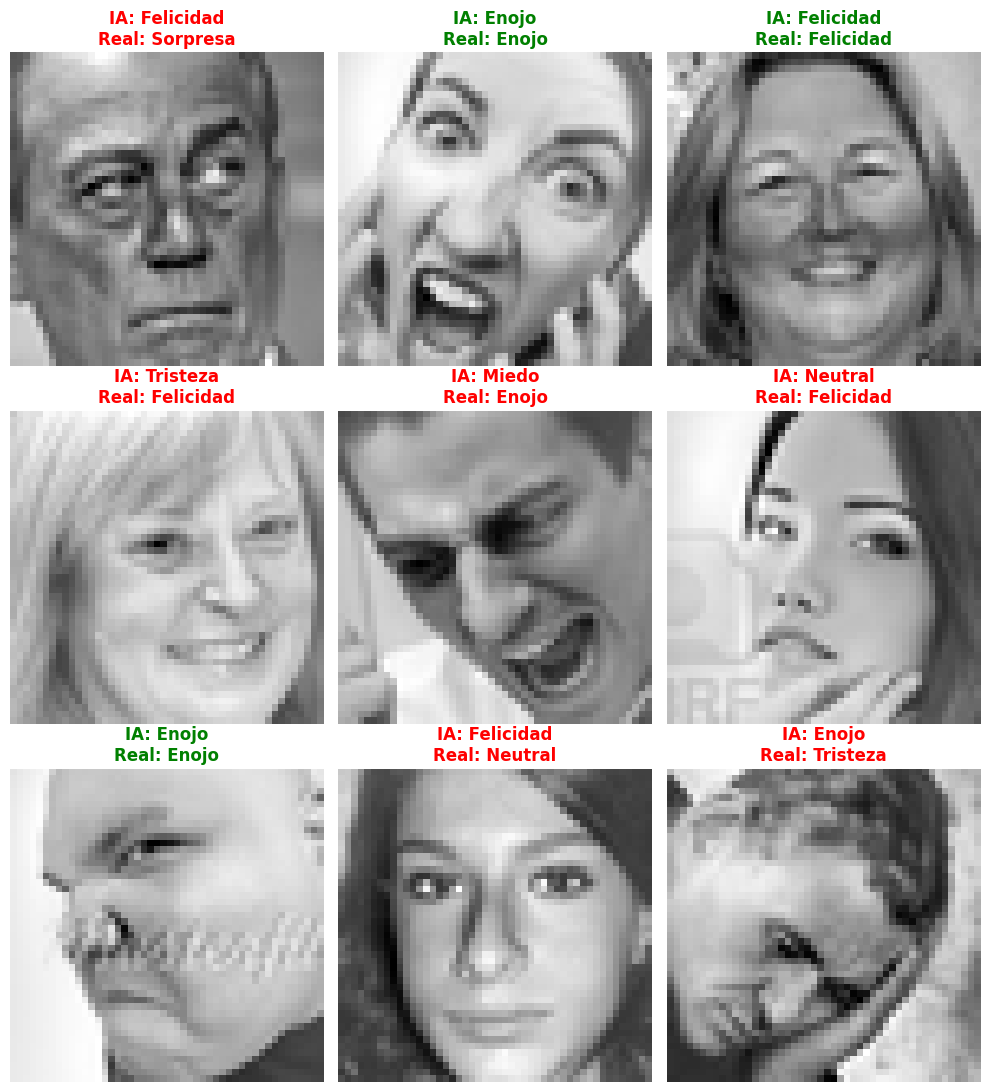

In [11]:
# FASE 6: PREDICCIÓN Y VISUALIZACIÓN DE ROSTROS

def predecirOneVsAll(all_theta, X):
    # Evaluamos la probabilidad de las 7 emociones a la vez
    h = sigmoid(np.dot(X, all_theta.T))
    # Nos quedamos con el índice de la emoción con mayor probabilidad
    predicciones = np.argmax(h, axis=1)
    return predicciones

print("Evaluando el modelo contra las imágenes de prueba...")
predicciones_test = predecirOneVsAll(all_theta, X_test_listo)

# Cálculo de la Precisión Global
precision_real = np.mean(predicciones_test == y_test) * 100

print(f"\n{'='*50}")
print(f"RESULTADO DEL DATASET MULTIMODAL")
print(f"{'='*50}")
print(f"Imágenes evaluadas: {len(y_test)}")
print(f"PRECISIÓN GLOBAL: {precision_real:.2f}%")
print(f"{'='*50}\n")

print("Generando reconstrucción visual de los rostros...")

# Vamos a mostrar una cuadrícula de 3x3 con 9 imágenes aleatorias del Test Set
fig, axes = plt.subplots(3, 3, figsize=(10, 11))
axes = axes.ravel()

# Seleccionamos 9 índices al azar
indices_aleatorios = np.random.choice(len(y_test), 9, replace=False)

for i, idx in enumerate(indices_aleatorios):
    # 1. Extraemos los píxeles reales (ignorando la columna 0 que es el uno del sesgo)
    # y los redimensionamos de vuelta a su forma de imagen 48x48
    imagen_reconstruida = X_test_listo[idx, 1:].reshape(48, 48)

    # 2. Obtenemos los textos de la predicción y el valor real
    emocion_predicha = nombres_emociones[predicciones_test[idx]]
    emocion_real = nombres_emociones[y_test[idx]]

    # 3. Dibujamos la imagen
    axes[i].imshow(imagen_reconstruida, cmap='gray')
    axes[i].axis('off')

    # Ponemos el título en verde si acertó, y en rojo si falló
    color_texto = 'green' if emocion_predicha == emocion_real else 'red'
    titulo = f"IA: {emocion_predicha}\nReal: {emocion_real}"
    axes[i].set_title(titulo, color=color_texto, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()